# Modelo base

```{admonition} Alcance
:class: tip
Las secciones 7.1 a 7.6 usan solo el entrenamiento. La sección 7.7 usa el test una sola vez, con el
modelo, el hiperparámetro y el tamaño de la lista ya elegidos. Semilla 2026; los intervalos son por
bootstrap de personas (1.000 réplicas).
```

## Modelos comparados y métricas

| modelo | para qué |
|---|---|
| `DummyClassifier(strategy='prior')` | puntúa a todos con la prevalencia: el piso de cualquier métrica de ordenamiento |
| `DummyClassifier(strategy='stratified')` | predice al azar con la proporción de clases: el piso de la matriz de confusión |
| `LogisticRegression(class_weight='balanced')` | regresión logística regularizada (L2) que da más peso a la clase minoritaria |
| `LogisticRegression` sin pesos | la misma sin pesos, con probabilidades calibradas por construcción |

La métrica principal es la PR-AUC (precisión promedio). Como métrica operativa se reporta la
captura en el 10 % de mayor riesgo de cada mes. En las métricas con umbral (exactitud, precisión,
exhaustividad, F1 y F2) el umbral es el tamaño de la lista mensual: se marca la fracción *q* de mayor
puntaje de cada mes. El F2 pesa la exhaustividad cuatro veces más que la precisión, lo que refleja
el costo relativo del problema: es preferible conversar con alguien que no iba a renunciar que dejar
de ver a quien sí.

Con VP, FP, FN y VN las cuatro celdas de la matriz de confusión (verdaderos y falsos positivos,
falsos y verdaderos negativos),

$$
\text{precisión} = \frac{VP}{VP + FP}, \qquad
\text{exhaustividad} = \frac{VP}{VP + FN}, \qquad
\text{especificidad} = \frac{VN}{VN + FP}, \qquad
\text{exactitud} = \frac{VP + VN}{n},
$$

$$
F_\beta = (1 + \beta^2) \, \frac{\text{precisión} \cdot \text{exhaustividad}}
  {\beta^2 \, \text{precisión} + \text{exhaustividad}},
$$

con $\beta = 1$ para el F1 y $\beta = 2$ para el F2. La PR-AUC se calcula como precisión promedio,
$AP = \sum_k (R_k - R_{k-1}) P_k$, donde $P_k$ y $R_k$ son la precisión y la exhaustividad al marcar
los *k* puntajes más altos. El puntaje de Brier, $\frac{1}{n} \sum_i (\hat p_i - y_i)^2$, mide la
calidad de las probabilidades y no solo del orden. En la versión balanceada cada clase *c* recibe el
peso $w_c = n / (2 n_c)$, así que cada renuncia pesa unas 92 veces lo que pesa una no renuncia.

```{admonition} Observación
:class: note
Con 1 % de positivos, el ROC-AUC puede ser alto aunque el modelo sirva poco en la práctica, porque
premia ordenar bien la gran masa de negativos. La PR-AUC se concentra en los positivos y su piso es
la prevalencia (≈ 0,01), no 0,5.
```

## Implementación: `Pipeline`

Todo el preprocesamiento está dentro del `Pipeline`; en cada pliegue se ajusta solo con sus
filas de entrenamiento. Cada paso responde a un resultado del análisis exploratorio:

| paso | motivo |
|---|---|
| numéricas: imputación por la mediana (1 nulo en edad) y estandarización | la regularización L2 requiere escalas comparables |
| antigüedad también en logaritmo | el riesgo cae rápido el primer año y luego se aplana (3.2) |
| categóricas: el nulo como categoría propia | en `familia_cargo` y `oficio` el nulo es el primer mes y tiene más riesgo (1.4) |
| una columna por categoría; las de menos de 300 filas y las nuevas del test se agrupan | 33 de 57 ubicaciones tienen menos de 5 renuncias (3.4) |
| mes del año como categórica | enero es el pico en los dos años (5.2) |
| sin tratamiento de atípicos | los valores extremos de edad y antigüedad son reales (1.5) |

## Validación

Se usa la validación temporal descrita en la sección 2.3 (ventana creciente, un mes de separación,
ocho pliegues de septiembre de 2025 a abril de 2026) y, como complemento, la agrupada por persona.

In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GroupKFold, learning_curve
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss, roc_curve,
                             precision_recall_curve, confusion_matrix)
from sklearn.calibration import calibration_curve
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
from comun import (cargar, particion, estilo, etiquetar, pliegues_temporales, marcar_top,
                   metricas_umbral, OBJETIVO, NUM, BIN, CAT, SEMILLA, CORTE, NOMBRE,
                   VERDE, ORO, TINTA, GRIS, BORDE)

estilo()

# Datos
p = cargar()
p['mes_anio'] = p.mes.str[5:]
tr, te = particion(p)
tr = tr.reset_index(drop=True)
te = te.reset_index(drop=True)

CAT_MODELO = CAT + ['mes_anio']
X_COLS = NUM + BIN + CAT_MODELO
Xtr, ytr = tr[X_COLS], tr[OBJETIVO].to_numpy()
gtr, mtr = tr.persona_id.to_numpy(), tr.mes.to_numpy()


# Pipeline
def preprocesador():
    log_antig = make_pipeline(FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
                              StandardScaler())
    categoricas = make_pipeline(
        SimpleImputer(strategy='constant', fill_value='(nulo)'),
        OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=300),
    )
    return ColumnTransformer([
        ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), NUM),
        ('log_antig', log_antig, ['antig_meses']),
        ('bin', 'passthrough', BIN),
        ('cat', categoricas, CAT_MODELO),
    ])


def modelo(clf):
    return Pipeline([('prep', preprocesador()), ('clf', clf)])


# Métricas
def captura_top(y, s, meses, q=0.10):
    """Fracción de las renuncias que quedan dentro de la lista mensual del q de mayor riesgo."""
    marca = marcar_top(s, meses, q)
    return marca[y == 1].mean() if y.sum() else np.nan


def metricas(y, s, meses):
    return {'PR-AUC': average_precision_score(y, s), 'ROC-AUC': roc_auc_score(y, s),
            'Brier': brier_score_loss(y, s), 'captura top 10 %': captura_top(y, s, meses)}


# Validación temporal y agrupada
PT = pliegues_temporales(mtr)
PG = list(GroupKFold(5).split(Xtr, ytr, gtr))
print('pliegues temporales:')
for ent, val in PT:
    print(f'   valida {mtr[val][0]} ({len(val):,} filas, {int(ytr[val].sum())} renuncias) | '
          f'entrena {mtr[ent].min()} a {mtr[ent].max()} ({len(ent):,} filas)')
n_columnas = len(modelo(LogisticRegression()).fit(Xtr, ytr)[:-1].get_feature_names_out())
print(f'columnas tras el preprocesamiento: {n_columnas} a partir de {len(X_COLS)} variables')

pliegues temporales:
   valida 2025-09 (4,256 filas, 49 renuncias) | entrena 2025-01 a 2025-07 (28,658 filas)
   valida 2025-10 (4,253 filas, 32 renuncias) | entrena 2025-01 a 2025-08 (32,877 filas)
   valida 2025-11 (4,295 filas, 41 renuncias) | entrena 2025-01 a 2025-09 (37,133 filas)
   valida 2025-12 (4,288 filas, 41 renuncias) | entrena 2025-01 a 2025-10 (41,386 filas)
   valida 2026-01 (4,329 filas, 66 renuncias) | entrena 2025-01 a 2025-11 (45,681 filas)
   valida 2026-02 (4,376 filas, 40 renuncias) | entrena 2025-01 a 2025-12 (49,969 filas)
   valida 2026-03 (4,423 filas, 35 renuncias) | entrena 2025-01 a 2026-01 (54,298 filas)
   valida 2026-04 (4,433 filas, 40 renuncias) | entrena 2025-01 a 2026-02 (58,674 filas)


columnas tras el preprocesamiento: 183 a partir de 19 variables


## Regularización

`C` es el inverso de la fuerza de la penalización L2. Se elige por la PR-AUC media de los ocho
pliegues temporales.

In [2]:
def por_pliegue(clf, pliegues, con_entrenamiento=False):
    """Métricas por pliegue y predicciones fuera de pliegue."""
    filas = []
    oof = np.full(len(ytr), np.nan)
    for k, (ent, val) in enumerate(pliegues):
        m = modelo(clf).fit(Xtr.iloc[ent], ytr[ent])
        s_val = m.predict_proba(Xtr.iloc[val])[:, 1]
        oof[val] = s_val
        fila = {'pliegue': k + 1, 'mes_val': mtr[val][0],
                'PR val': average_precision_score(ytr[val], s_val),
                'ROC val': roc_auc_score(ytr[val], s_val)}
        if con_entrenamiento:
            s_ent = m.predict_proba(Xtr.iloc[ent])[:, 1]
            fila['PR ent'] = average_precision_score(ytr[ent], s_ent)
            fila['ROC ent'] = roc_auc_score(ytr[ent], s_ent)
        filas.append(fila)
    return pd.DataFrame(filas), oof


res_c = {}
for C in [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.1, 1]:
    t, _ = por_pliegue(LogisticRegression(class_weight='balanced', C=C, max_iter=3000), PT)
    res_c[C] = {'PR-AUC media': t['PR val'].mean(), 'PR-AUC de': t['PR val'].std(),
                'ROC-AUC media': t['ROC val'].mean()}
res_c = pd.DataFrame(res_c).T.rename_axis('C')
print(res_c.round(4).to_string())

C_MEJOR = float(res_c['PR-AUC media'].idxmax())
print(f'\nC elegido: {C_MEJOR}')

MODELOS = {
    'dummy_prior': DummyClassifier(strategy='prior'),
    'dummy_estratificado': DummyClassifier(strategy='stratified', random_state=SEMILLA),
    'logistica_balanceada': LogisticRegression(class_weight='balanced', C=C_MEJOR, max_iter=3000),
    'logistica_sin_pesos': LogisticRegression(C=C_MEJOR, max_iter=3000),
}

        PR-AUC media  PR-AUC de  ROC-AUC media
C                                             
0.0001        0.0299     0.0089         0.7619
0.0003        0.0324     0.0088         0.7668
0.0010        0.0348     0.0083         0.7690
0.0030        0.0352     0.0078         0.7675
0.0100        0.0352     0.0073         0.7635
0.1000        0.0331     0.0058         0.7541
1.0000        0.0305     0.0064         0.7448

C elegido: 0.003


## Comparación de modelos en validación

Todos los modelos se evalúan en los mismos pliegues, de modo que las diferencias se prueban pareadas por
pliegue: prueba *t* pareada y, como con ocho pliegues no se puede verificar la normalidad, también
Wilcoxon de rangos con signo.

In [3]:
PF, OOF = {}, {}
for nombre, clf in MODELOS.items():
    PF[nombre], OOF[nombre] = por_pliegue(clf, PT, con_entrenamiento=nombre.startswith('logistica'))

tabla = pd.DataFrame({n: {'PR-AUC temporal': PF[n]['PR val'].mean(),
                          'ROC-AUC temporal': PF[n]['ROC val'].mean()} for n in MODELOS}).T
for nombre, clf in MODELOS.items():
    t, _ = por_pliegue(clf, PG)
    tabla.loc[nombre, 'PR-AUC agrupada'] = t['PR val'].mean()
    tabla.loc[nombre, 'ROC-AUC agrupada'] = t['ROC val'].mean()
print(tabla.round(4).to_string())


def pareada(a, b, etiqueta):
    d = PF[a]['PR val'].to_numpy() - PF[b]['PR val'].to_numpy()
    t = stats.ttest_rel(PF[a]['PR val'], PF[b]['PR val'])
    w = stats.wilcoxon(d)
    ic = stats.t.interval(0.95, len(d) - 1, d.mean(), stats.sem(d))
    print(f'{etiqueta}: diferencia media de PR-AUC {d.mean():+.4f} '
          f'(IC 95 % {ic[0]:+.4f} a {ic[1]:+.4f}) | t pareada p = {t.pvalue:.4f} | '
          f'Wilcoxon p = {w.pvalue:.4f} | gana en {int((d > 0).sum())} de {len(d)} pliegues')


print()
pareada('logistica_balanceada', 'dummy_prior', 'balanceada frente a dummy')
pareada('logistica_sin_pesos', 'dummy_prior', 'sin pesos frente a dummy')
pareada('logistica_balanceada', 'logistica_sin_pesos', 'balanceada frente a sin pesos')

PRINCIPAL = max(['logistica_balanceada', 'logistica_sin_pesos'],
                key=lambda n: PF[n]['PR val'].mean())
print(f'\nmodelo principal (mayor PR-AUC temporal): {PRINCIPAL}')

                      PR-AUC temporal  ROC-AUC temporal  PR-AUC agrupada  ROC-AUC agrupada
dummy_prior                    0.0099            0.5000           0.0108            0.5000
dummy_estratificado            0.0101            0.5007           0.0109            0.5005
logistica_balanceada           0.0352            0.7675           0.0387            0.7630
logistica_sin_pesos            0.0317            0.7660           0.0361            0.7575

balanceada frente a dummy: diferencia media de PR-AUC +0.0253 (IC 95 % +0.0198 a +0.0308) | t pareada p = 0.0000 | Wilcoxon p = 0.0078 | gana en 8 de 8 pliegues
sin pesos frente a dummy: diferencia media de PR-AUC +0.0218 (IC 95 % +0.0155 a +0.0281) | t pareada p = 0.0001 | Wilcoxon p = 0.0078 | gana en 8 de 8 pliegues
balanceada frente a sin pesos: diferencia media de PR-AUC +0.0035 (IC 95 % +0.0005 a +0.0064) | t pareada p = 0.0267 | Wilcoxon p = 0.0391 | gana en 7 de 8 pliegues

modelo principal (mayor PR-AUC temporal): logistica_balan

## Diagnóstico de sobreajuste

Comparamos el desempeño en las filas de entrenamiento de cada pliegue con el de su mes de
validación. Se prueba si la brecha media es cero (*t* de una muestra y Wilcoxon) y se lee su tamaño
relativo con los umbrales del curso: menos de 5 a 10 % es aceptable y más de 15 a 20 % indica
sobreajuste.

In [4]:
f = PF[PRINCIPAL].copy()
for m in ['PR', 'ROC']:
    f[f'brecha {m}'] = f[f'{m} ent'] - f[f'{m} val']
columnas = ['mes_val', 'PR ent', 'PR val', 'brecha PR', 'ROC ent', 'ROC val', 'brecha ROC']
print(f[columnas].round(4).to_string(index=False))

for m in ['PR', 'ROC']:
    d = f[f'brecha {m}'].to_numpy()
    ic = stats.t.interval(0.95, len(d) - 1, d.mean(), stats.sem(d))
    relativa = 100 * d.mean() / f[f'{m} ent'].mean()
    print(f'\nbrecha {m}-AUC: media {d.mean():+.4f} (IC 95 % {ic[0]:+.4f} a {ic[1]:+.4f}), '
          f'relativa {relativa:.1f} % | t p = {stats.ttest_1samp(d, 0).pvalue:.4f} | '
          f'Wilcoxon p = {stats.wilcoxon(d).pvalue:.4f}')

mes_val  PR ent  PR val  brecha PR  ROC ent  ROC val  brecha ROC
2025-09  0.0489  0.0434     0.0055   0.7923   0.7626      0.0298
2025-10  0.0493  0.0244     0.0249   0.7902   0.7938     -0.0036
2025-11  0.0469  0.0245     0.0224   0.7901   0.7548      0.0352
2025-12  0.0449  0.0421     0.0028   0.7930   0.7652      0.0277
2026-01  0.0443  0.0429     0.0015   0.7921   0.7493      0.0428
2026-02  0.0437  0.0363     0.0074   0.7904   0.7795      0.0110
2026-03  0.0428  0.0369     0.0059   0.7894   0.7570      0.0324
2026-04  0.0424  0.0313     0.0111   0.7887   0.7774      0.0113

brecha PR-AUC: media +0.0102 (IC 95 % +0.0028 a +0.0175), relativa 22.4 % | t p = 0.0139 | Wilcoxon p = 0.0078

brecha ROC-AUC: media +0.0233 (IC 95 % +0.0104 a +0.0363), relativa 2.9 % | t p = 0.0038 | Wilcoxon p = 0.0156


La brecha que se compara con los umbrales del curso es la de ROC-AUC, porque su escala es comparable
entre conjuntos. La PR-AUC depende de la prevalencia de cada conjunto (cada mes validado tiene su
propia tasa y pocas renuncias), y por eso su brecha relativa es más ruidosa.

### Curva de aprendizaje

Para saber si el modelo mejoraría con más datos, se entrena con fracciones crecientes de cada
ventana temporal y se mide la PR-AUC en su mes de validación.

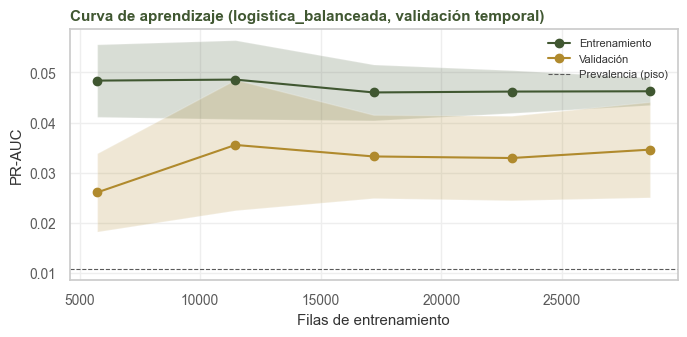

 filas  PR-AUC entrenamiento  PR-AUC validación
  5731                0.0484             0.0261
 11463                0.0486             0.0355
 17194                0.0460             0.0332
 22926                0.0462             0.0329
 28658                0.0462             0.0346


In [5]:
tam, sc_ent, sc_val = learning_curve(
    modelo(MODELOS[PRINCIPAL]), Xtr, ytr, cv=PT, train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
    scoring='average_precision', n_jobs=1, shuffle=True, random_state=SEMILLA,
)
# learning_curve usa los mismos tamaños absolutos en todos los pliegues, tomados de la ventana más
# corta (28.658 filas)

fig, ax = plt.subplots(figsize=(7, 3.5))
for sc, etiqueta in [(sc_ent, 'Entrenamiento'), (sc_val, 'Validación')]:
    ax.plot(tam, sc.mean(1), marker='o', label=etiqueta)
    ax.fill_between(tam, sc.mean(1) - sc.std(1), sc.mean(1) + sc.std(1), alpha=0.2)
ax.axhline(ytr.mean(), c=GRIS, ls='--', lw=0.8, label='Prevalencia (piso)')
ax.set(title=f'Curva de aprendizaje ({PRINCIPAL}, validación temporal)',
       xlabel='Filas de entrenamiento', ylabel='PR-AUC')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(pd.DataFrame({'filas': tam, 'PR-AUC entrenamiento': sc_ent.mean(1),
                    'PR-AUC validación': sc_val.mean(1)}).round(4).to_string(index=False))

### Tamaño de la lista que maximiza el F2

Con las predicciones fuera de pliegue de la validación temporal se busca la fracción mensual *q*
que maximiza el F2. Se decide con el entrenamiento, y en el test solo se aplica.

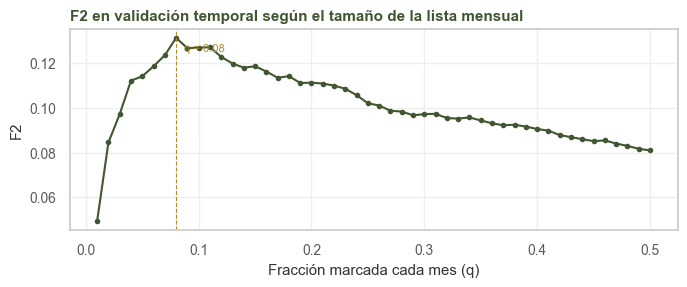

q que maximiza el F2 en validación: 0.08 (F2 = 0.131); con q = 0,10 el F2 es 0.127
F2 en validación para algunos tamaños: {0.03: 0.097, 0.05: 0.114, 0.08: 0.131, 0.1: 0.127, 0.15: 0.119, 0.2: 0.111, 0.3: 0.097}


In [6]:
ok = ~np.isnan(OOF[PRINCIPAL])
qs = np.round(np.arange(0.01, 0.51, 0.01), 2)
f2 = pd.Series({q: metricas_umbral(ytr[ok], marcar_top(OOF[PRINCIPAL][ok], mtr[ok], q))['F2']
                for q in qs})
Q_F2 = float(f2.idxmax())

fig, ax = plt.subplots(figsize=(7, 3))
f2.plot(ax=ax, marker='.')
ax.axvline(Q_F2, c=ORO, ls='--', lw=0.8)
ax.annotate(f'q = {Q_F2:.2f}', (Q_F2, f2.max()), textcoords='offset points', xytext=(6, -10),
            fontsize=8, color=ORO)
ax.set(title='F2 en validación temporal según el tamaño de la lista mensual',
       xlabel='Fracción marcada cada mes (q)', ylabel='F2')
plt.tight_layout()
plt.show()

print(f'q que maximiza el F2 en validación: {Q_F2:.2f} (F2 = {f2.max():.3f}); '
      f'con q = 0,10 el F2 es {f2[0.10]:.3f}')
print('F2 en validación para algunos tamaños:',
      f2[[0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]].round(3).to_dict())

## Evaluación en el test

Cada modelo se reentrena con todo el entrenamiento (enero de 2025 a abril de 2026) y se evalúa en
los meses de mayo a agosto de 2026.

In [7]:
Xte, yte = te[X_COLS], te[OBJETIVO].to_numpy()
gte, mte = te.persona_id.to_numpy(), te.mes.to_numpy()

FIN = {nombre: modelo(clf).fit(Xtr, ytr) for nombre, clf in MODELOS.items()}
ST = {nombre: m.predict_proba(Xte)[:, 1] for nombre, m in FIN.items()}
PRED_DE = FIN['dummy_estratificado'].predict(Xte)

# bootstrap de personas: se remuestrean personas con todos sus meses
rng = np.random.default_rng(SEMILLA)
personas = np.unique(gte)
filas_de = pd.Series(np.arange(len(gte))).groupby(gte).apply(np.array).to_dict()
REPS = [np.concatenate([filas_de[q] for q in rng.choice(personas, len(personas))])
        for _ in range(1000)]


def boot(fun):
    """Percentiles 2,5 y 97,5 de una métrica sobre las réplicas con al menos una renuncia."""
    valores = pd.DataFrame([fun(ii) for ii in REPS if yte[ii].sum() > 0])
    return valores.quantile(0.025), valores.quantile(0.975)


def con_ic(punto, bajo, alto):
    return {k: f'{punto[k]:.4f} [{bajo[k]:.4f}, {alto[k]:.4f}]' for k in punto}


resultados = {}
for nombre, s in ST.items():
    bajo, alto = boot(lambda ii: metricas(yte[ii], s[ii], mte[ii]))
    resultados[nombre] = con_ic(metricas(yte, s, mte), bajo, alto)
print(f'test: {len(yte):,} filas, {int(yte.sum())} renuncias, prevalencia {yte.mean():.4f}')
pd.DataFrame(resultados).T

test: 17,693 filas, 162 renuncias, prevalencia 0.0092


,PR-AUC,ROC-AUC,Brier,captura top 10 %
dummy_prior,"0.0092 [0.0079, 0.0106]","0.5000 [0.5000, 0.5000]","0.0091 [0.0078, 0.0105]","0.1173 [0.0559, 0.1523]"
dummy_estratificado,"0.0092 [0.0079, 0.0106]","0.4944 [0.4937, 0.4951]","0.0202 [0.0182, 0.0222]","0.1173 [0.0489, 0.1404]"
logistica_balanceada,"0.0291 [0.0219, 0.0444]","0.7615 [0.7297, 0.7947]","0.1924 [0.1869, 0.1978]","0.3148 [0.2400, 0.3867]"
logistica_sin_pesos,"0.0310 [0.0223, 0.0491]","0.7548 [0.7210, 0.7882]","0.0090 [0.0077, 0.0103]","0.3210 [0.2406, 0.3923]"


La logística triplica la PR-AUC de los dummies (0,029 y 0,031 frente a 0,009, sin solape de
intervalos) y obtiene un ROC-AUC de 0,76. Las dos versiones ordenan igual: sus intervalos se
solapan casi por completo. Difieren en el Brier: la versión sin pesos obtiene 0,009, como el dummy
que predice la prevalencia, y la balanceada 0,192, porque sus probabilidades están infladas. El 10 %
de mayor riesgo reúne entre el 31 % y el 32 % de las renuncias, frente al 12 % de marcar al azar.

### Métricas con umbral

Para cada modelo, con la lista del 10 % mensual y con la del *q* que maximizó el F2 en validación.
El dummy estratificado usa su propia predicción al azar.

In [8]:
resultados = {}
for nombre in ['logistica_balanceada', 'logistica_sin_pesos', 'dummy_prior']:
    s = ST[nombre]
    for q in sorted({0.10, Q_F2}):
        punto = metricas_umbral(yte, marcar_top(s, mte, q))
        bajo, alto = boot(lambda ii: metricas_umbral(yte[ii], marcar_top(s[ii], mte[ii], q)))
        resultados[(nombre, f'q = {q:.2f}')] = con_ic(punto, bajo, alto)
bajo, alto = boot(lambda ii: metricas_umbral(yte[ii], PRED_DE[ii]))
resultados[('dummy_estratificado', 'predict')] = con_ic(metricas_umbral(yte, PRED_DE), bajo, alto)

todos = metricas_umbral(yte, np.ones(len(yte), int))
print(f'referencia "marcar a todos": precisión {todos["precisión"]:.4f}, exhaustividad 1, '
      f'F1 {todos["F1"]:.4f}, F2 {todos["F2"]:.4f}')
pd.DataFrame(resultados).T

referencia "marcar a todos": precisión 0.0092, exhaustividad 1, F1 0.0181, F2 0.0442


exactitud  \
logistica_balanceada q = 0.08  0.9155 [0.9141, 0.9170]   
                     q = 0.10  0.8966 [0.8951, 0.8980]   
logistica_sin_pesos  q = 0.08  0.9156 [0.9142, 0.9169]   
                     q = 0.10  0.8967 [0.8950, 0.8981]   
dummy_prior          q = 0.08  0.9128 [0.9109, 0.9137]   
                     q = 0.10  0.8930 [0.8913, 0.8941]   
dummy_estratificado  predict   0.9798 [0.9778, 0.9818]   

                                             precisión  \
logistica_balanceada q = 0.08  0.0290 [0.0212, 0.0376]   
                     q = 0.10  0.0288 [0.0209, 0.0357]   
logistica_sin_pesos  q = 0.08  0.0297 [0.0205, 0.0376]   
                     q = 0.10  0.0294 [0.0209, 0.0363]   
dummy_prior          q = 0.08  0.0120 [0.0043, 0.0148]   
                     q = 0.10  0.0107 [0.0051, 0.0142]   
dummy_estratificado  predict   0.0000 [0.0000, 0.0000]   

                                         exhaustividad  \
logistica_balanceada q = 0.08  0.2531 [0.1890, 0.3243]   
                     q = 0.10  0.3148 [0.2400, 0.3867]   
logistica_sin_pesos  q = 0.08  0.2593 [0.1879, 0.3182]   
                     q = 0.10  0.3210 [0.2406, 0.3923]   
dummy_prior          q = 0.08  0.1049 [0.0390, 0.1267]   
                     q = 0.10  0.1173 [0.0559, 0.1523]   
dummy_estratificado  predict   0.0000 [0.0000, 0.0000]   

                                         especificidad  \
logistica_balanceada q = 0.08  0.9216 [0.9210, 0.9223]   
                     q = 0.10  0.9020 [0.9013, 0.9027]   
logistica_sin_pesos  q = 0.08  0.9217 [0.9210, 0.9223]   
                     q = 0.10  0.9021 [0.9013, 0.9027]   
dummy_prior          q = 0.08  0.9203 [0.9196, 0.9204]   
                     q = 0.10  0.9002 [0.8996, 0.9005]   
dummy_estratificado  predict   0.9889 [0.9874, 0.9903]   

                                                    F1  \
logistica_balanceada q = 0.08  0.0520 [0.0382, 0.0673]   
                     q = 0.10  0.0528 [0.0384, 0.0654]   
logistica_sin_pesos  q = 0.08  0.0533 [0.0372, 0.0675]   
                     q = 0.10  0.0539 [0.0386, 0.0663]   
dummy_prior          q = 0.08  0.0216 [0.0077, 0.0264]   
                     q = 0.10  0.0197 [0.0093, 0.0259]   
dummy_estratificado  predict   0.0000 [0.0000, 0.0000]   

                                                    F2  
logistica_balanceada q = 0.08  0.0994 [0.0736, 0.1276]  
                     q = 0.10  0.1055 [0.0778, 0.1304]  
logistica_sin_pesos  q = 0.08  0.1018 [0.0723, 0.1278]  
                     q = 0.10  0.1076 [0.0785, 0.1317]  
dummy_prior          q = 0.08  0.0412 [0.0153, 0.0497]  
                     q = 0.10  0.0393 [0.0187, 0.0515]  
dummy_estratificado  predict   0.0000 [0.0000, 0.0000]

Con las listas del 8 % y del 10 %, la logística casi triplica la precisión y la exhaustividad del
dummy que marca la misma cantidad de filas al azar (con la lista del 10 %, 0,029 frente a 0,011 de
precisión y 0,31 frente a 0,12 de exhaustividad), y su F2 (0,11) es más del doble del de marcar a
todos (0,044). La exactitud y la especificidad no distinguen a los modelos: van de 0,89 a 0,98, y el
valor más alto es el del dummy estratificado, que no encuentra ninguna renuncia.

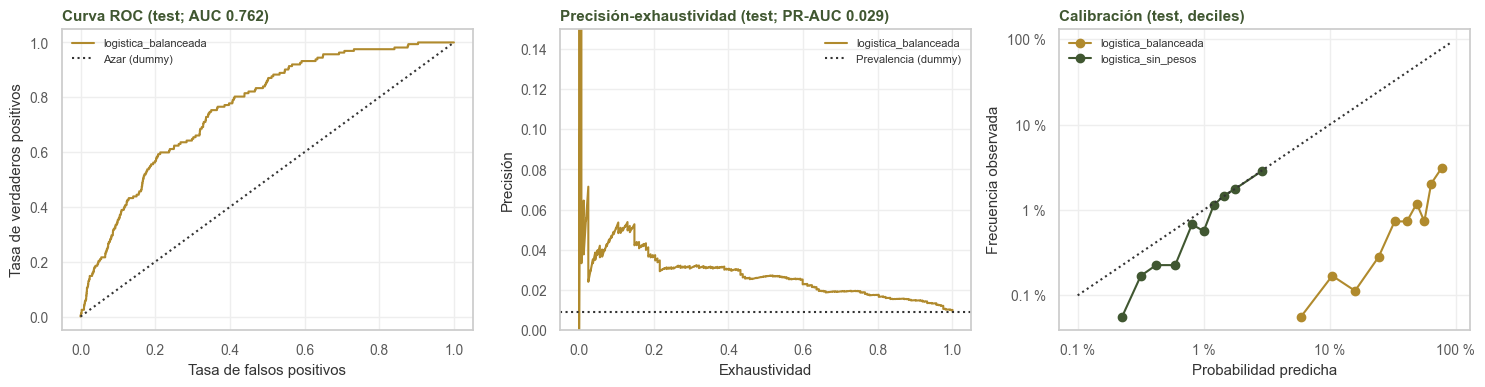

In [9]:
s = ST[PRINCIPAL]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

fpr, tpr, _ = roc_curve(yte, s)
ax[0].plot(fpr, tpr, label=PRINCIPAL, color=ORO)
# el dummy puntúa a todos igual: su ROC es la diagonal y su curva PR, la línea de la prevalencia
ax[0].plot([0, 1], [0, 1], ls=':', c=TINTA, label='Azar (dummy)')
ax[0].set(title=f'Curva ROC (test; AUC {roc_auc_score(yte, s):.3f})',
          xlabel='Tasa de falsos positivos', ylabel='Tasa de verdaderos positivos')
ax[0].legend(fontsize=8)

precision, exhaustividad, _ = precision_recall_curve(yte, s)
ax[1].plot(exhaustividad, precision, label=PRINCIPAL, color=ORO)
ax[1].axhline(yte.mean(), ls=':', c=TINTA, label='Prevalencia (dummy)')
ax[1].set_ylim(0, 0.15)
ax[1].set(title=f'Precisión-exhaustividad (test; PR-AUC {average_precision_score(yte, s):.3f})',
          xlabel='Exhaustividad', ylabel='Precisión')
ax[1].legend(fontsize=8)

for nombre, color in [('logistica_balanceada', ORO), ('logistica_sin_pesos', VERDE)]:
    observada, predicha = calibration_curve(yte, ST[nombre], n_bins=10, strategy='quantile')
    ax[2].plot(predicha, observada, marker='o', label=nombre, color=color)
lim = max(ST['logistica_balanceada'].max(), 0.05)
ax[2].plot([1e-3, lim], [1e-3, lim], ls=':', c=TINTA)
ax[2].set(title='Calibración (test, deciles)', xlabel='Probabilidad predicha',
          ylabel='Frecuencia observada', xscale='log', yscale='log')
# escala log con rótulos en porcentaje en lugar de potencias de 10
for eje in (ax[2].xaxis, ax[2].yaxis):
    eje.set_major_formatter(FuncFormatter(lambda v, _: f'{100 * v:g} %'))
    eje.set_minor_formatter(NullFormatter())
ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

La curva ROC se separa de la diagonal en todo el recorrido y sube más rápido al principio: los
puntajes más altos concentran renuncias. En la curva de precisión-exhaustividad la precisión es
inestable con exhaustividad baja, donde hay pocas renuncias marcadas; luego se mantiene entre 3 % y
5 % hasta una exhaustividad de 0,4 y baja hacia la prevalencia al final. La calibración confirma lo
que indica el Brier: la versión sin pesos sigue la diagonal, y la balanceada predice entre 8 % y
75 % donde la frecuencia observada va de 0,05 % a 3 %.

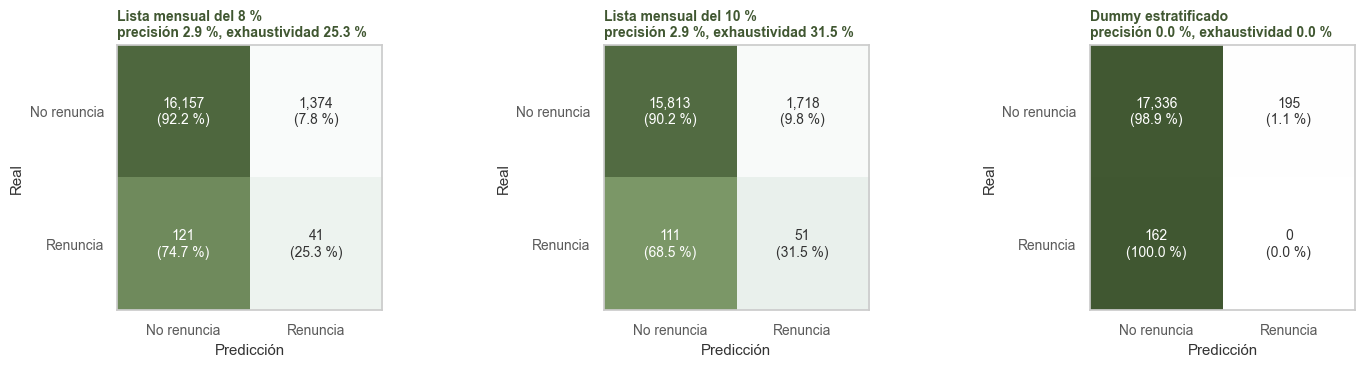

In [10]:
# Matrices de confusión en el test: conteo y porcentaje de la fila (la clase real)
casos = [(f'Lista mensual del {100 * q:.0f} %', marcar_top(s, mte, q)) for q in sorted({0.10, Q_F2})]
casos.append(('Dummy estratificado', PRED_DE))
fig, ax = plt.subplots(1, len(casos), figsize=(5 * len(casos), 3.8))
for a, (titulo, pred) in zip(ax, casos):
    cm = confusion_matrix(yte, pred)
    pct = cm / cm.sum(axis=1, keepdims=True)
    a.imshow(pct, cmap='verde', vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            color = 'white' if pct[i, j] > 0.5 else TINTA
            a.text(j, i, f'{cm[i, j]:,}\n({100 * pct[i, j]:.1f} %)', ha='center', va='center',
                   fontsize=10, color=color)
    precision = cm[1, 1] / max(cm[:, 1].sum(), 1)
    a.set_title(f'{titulo}\nprecisión {100 * precision:.1f} %, '
                f'exhaustividad {100 * cm[1, 1] / cm[1].sum():.1f} %', fontsize=10)
    a.set_xticks([0, 1], ['No renuncia', 'Renuncia'])
    a.set_yticks([0, 1], ['No renuncia', 'Renuncia'])
    a.set(xlabel='Predicción', ylabel='Real')
    a.grid(False)
plt.tight_layout()
plt.show()

Con la lista del 10 % se marcan 1.769 persona-mes del test, y 51 de ellas renuncian ese mes: una
precisión del 2,9 %, frente al 0,92 % de base. Una persona de la lista tiene 3,2 veces más
probabilidad de renunciar que una tomada al azar, y la lista recoge el 31 % de las 162 renuncias. El
dummy marca 195 persona-mes y no acierta ninguna.

La precisión es baja por la prevalencia, no solo por el modelo. En el test renuncia menos de una
persona de cada cien en un mes dado, y la lista del 10 % tiene 1.769 filas para 162 renuncias:
aunque el modelo pusiera todas las renuncias en la lista, la precisión no pasaría de 162 / 1.769 =
9,2 %. Una lista de la mitad del tamaño sube la precisión y baja la exhaustividad; la lista del 8 %,
elegida por F2, queda en 2,9 % y 25 %. Además, buena parte de lo que precipita una renuncia (una
oferta de otra empresa, un cambio personal) no está en los datos de nómina. Por eso el modelo se
lee como un ordenamiento del riesgo para priorizar a quién atender, no como un aviso individual.

## Residuos en el tiempo

Si los residuos tienen autocorrelación, queda estructura temporal que el modelo no captó. En una
clasificación, el residuo natural es mensual: renuncias observadas menos renuncias esperadas (la
suma de las probabilidades del mes), estandarizado por su desviación binomial. Se usan las
probabilidades del modelo sin pesos, que son las calibradas, en los ocho meses de validación
temporal y los cuatro de test.

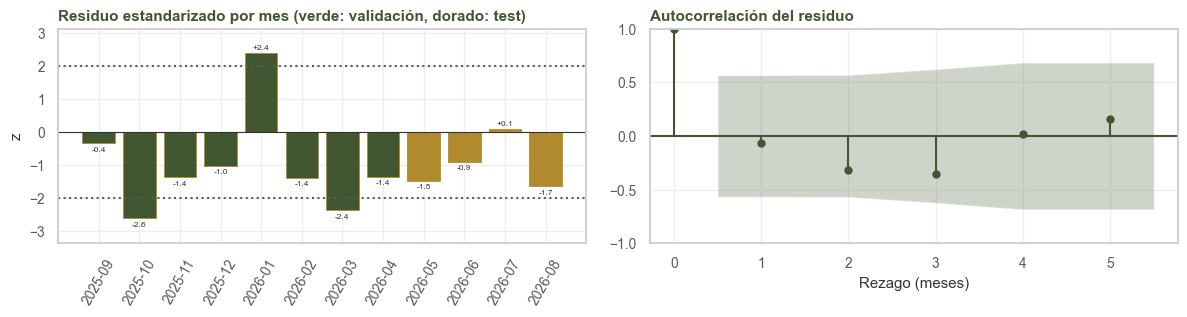

mes         2025-09  2025-10  2025-11  2025-12  2026-01  2026-02  2026-03  2026-04  2026-05  2026-06  2026-07  2026-08
observadas    49.00    32.00    41.00    41.00    66.00    40.00    35.00    40.00    38.00    40.00    49.00    35.00
esperadas     51.52    50.54    50.77    48.14    49.41    49.72    52.04    49.58    48.28    46.08    48.36    46.12
z             -0.35    -2.63    -1.38    -1.04     2.38    -1.39    -2.38    -1.37    -1.49    -0.90     0.09    -1.65

Ljung-Box (3 rezagos): [{'lb_stat': 4.096, 'lb_pvalue': 0.251}]


In [11]:
ok_s = ~np.isnan(OOF['logistica_sin_pesos'])
d = pd.concat([
    pd.DataFrame({'mes': mtr[ok_s], 'y': ytr[ok_s], 'p': OOF['logistica_sin_pesos'][ok_s]}),
    pd.DataFrame({'mes': mte, 'y': yte, 'p': ST['logistica_sin_pesos']}),
])


def residuo_mes(g):
    observadas, esperadas = g.y.sum(), g.p.sum()
    z = (observadas - esperadas) / np.sqrt((g.p * (1 - g.p)).sum())
    return pd.Series({'observadas': observadas, 'esperadas': esperadas, 'z': z})


r = d.groupby('mes').apply(residuo_mes)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
colores = [VERDE if mes < CORTE else ORO for mes in r.index]
barras = ax[0].bar(r.index, r.z, color=colores, **BORDE)
etiquetar(ax[0], barras, '{:+.1f}', fontsize=6)
ax[0].axhline(0, c=TINTA, lw=0.8)
ax[0].axhline(2, ls=':', c=GRIS)
ax[0].axhline(-2, ls=':', c=GRIS)
ax[0].tick_params(axis='x', rotation=60)
ax[0].set(title='Residuo estandarizado por mes (verde: validación, dorado: test)', ylabel='z')
plot_acf(r.z.to_numpy(), lags=5, ax=ax[1], color=VERDE, vlines_kwargs={'colors': VERDE})
ax[1].set(title='Autocorrelación del residuo', xlabel='Rezago (meses)')
plt.tight_layout()
plt.show()

print(r.round(2).T.to_string())
ljung_box = acorr_ljungbox(r.z.to_numpy(), lags=[3], return_df=True)
print('\nLjung-Box (3 rezagos):', ljung_box.round(3).to_dict('records'))

## Coeficientes del modelo

El modelo estima, para la persona *i* activa al inicio del mes *t*,

$$
\log \frac{p_{it}}{1 - p_{it}} = \beta_0 + \beta_1\, \text{edad}_{it} + \beta_2\, \text{antig}_{it}
  + \beta_3 \log(1 + \text{antig}_{it}) + \sum_{b} \gamma_b\, x^{\text{bin}}_{itb}
  + \sum_{v} \sum_{c} \delta_{vc}\, \mathbb{1}[x_{itv} = c],
$$

donde $p_{it}$ es la probabilidad de que renuncie en el mes *t*, las tres numéricas entran
estandarizadas, las binarias son `primer_mes`, `reingreso` y `traslado_12m`, y la última suma
recorre cada categoría *c* de cada variable categórica *v* (incluido el mes del año), con una
categoría adicional para las infrecuentes. Los coeficientes minimizan la log-verosimilitud negativa
más la penalización $\lVert \beta \rVert^2 / (2C)$, con $C = 0{,}003$.

Se interpretan como razones de momios, $e^{\beta}$, con tres cautelas:

- Las numéricas están estandarizadas: la razón de momios corresponde a una desviación estándar.
- Como hay una columna por categoría, sin categoría de referencia, cada coeficiente se compara con
  el promedio que fija la penalización. Lo interpretable es la diferencia entre dos categorías de
  la misma variable: $e^{\delta_{vc} - \delta_{vc'}}$ es la razón de momios de *c* frente a *c'*.
- Los pares anidados (sociedad y línea, oficio y familia) se reparten el efecto de forma arbitraria
  (capítulo 4).

El gráfico muestra las 24 columnas con más peso en el modelo principal.

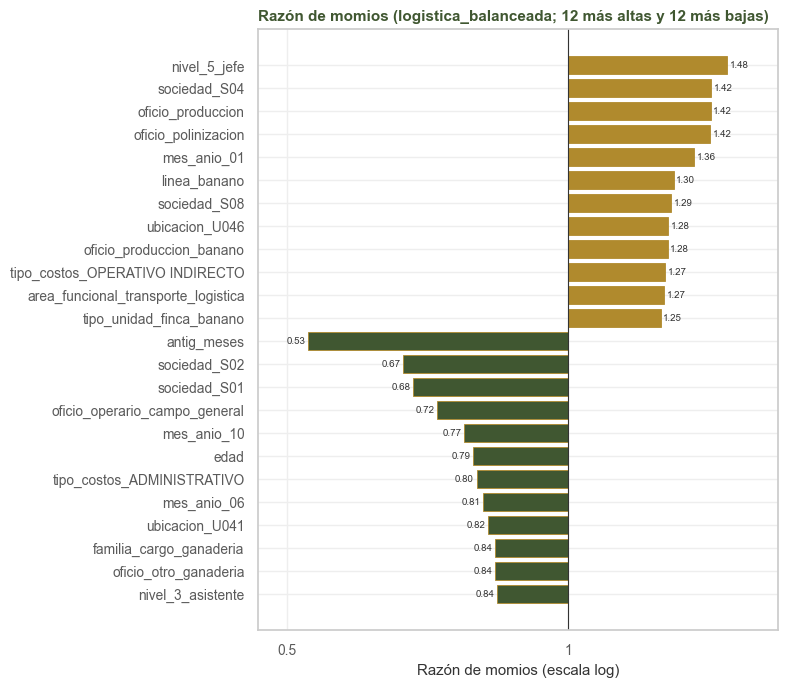

In [12]:
final = FIN[PRINCIPAL]
coef = pd.Series(final[-1].coef_[0], index=final[:-1].get_feature_names_out())
coef.index = (coef.index.str.replace('log_antig__antig_meses', 'log(antig_meses)')
              .str.replace(r'^\w+?__', '', regex=True))
top = pd.concat([coef.nlargest(12), coef.nsmallest(12)])[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
colores = [ORO if v > 0 else VERDE for v in top]
barras = ax.barh(top.index, np.exp(top) - 1, left=1, color=colores, **BORDE)   # barras desde OR = 1
etiquetar(ax, barras, textos=[f'{v:.2f}' for v in np.exp(top)])
ax.axvline(1, c=TINTA, lw=0.8)
ax.set(xscale='log', title=f'Razón de momios ({PRINCIPAL}; 12 más altas y 12 más bajas)',
       xlabel='Razón de momios (escala log)')
lo, hi = ax.get_xlim()
ax.set_xticks([t for t in [0.125, 0.25, 0.5, 1, 2, 4, 8] if lo <= t <= hi])
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
ax.xaxis.set_minor_formatter(NullFormatter())
plt.tight_layout()
plt.show()

La tabla completa trae, para cada columna, el coeficiente y la razón de momios del modelo principal
y del modelo sin pesos. Los dos van en la misma dirección (correlación de 0,74), pero con
magnitudes distintas: los pesos de clase desplazan el intercepto y, con la misma penalización,
pesan más la verosimilitud de las renuncias, de modo que los coeficientes del modelo balanceado
se encogen menos. Para calcular probabilidades se usa el modelo sin pesos, que está calibrado.

In [13]:
def tabla_coeficientes(nombre):
    m = FIN[nombre]
    columnas = m[:-1].get_feature_names_out()
    return pd.Series(np.r_[m[-1].intercept_, m[-1].coef_[0]], index=['intercepto', *columnas])


def separar(columna):
    """Nombre del ColumnTransformer -> (variable, categoría)."""
    if columna == 'intercepto':
        return 'intercepto', ''
    bloque, resto = columna.split('__', 1)
    if bloque == 'log_antig':
        return 'log(antig_meses)', ''
    if bloque in ('num', 'bin'):
        return resto, ''
    variable = next(v for v in CAT_MODELO if resto.startswith(v + '_'))
    categoria = resto[len(variable) + 1:].replace('infrequent_sklearn', '(infrecuentes)')
    return variable, categoria


coefs = pd.DataFrame({'coef. principal': tabla_coeficientes(PRINCIPAL),
                      'coef. sin pesos': tabla_coeficientes('logistica_sin_pesos')})
coefs['OR principal'] = np.exp(coefs['coef. principal'])
coefs['OR sin pesos'] = np.exp(coefs['coef. sin pesos'])
coefs.index = pd.MultiIndex.from_tuples([separar(c) for c in coefs.index],
                                        names=['variable', 'categoría'])
print(f'{len(coefs) - 1} coeficientes más el intercepto; '
      f'correlación entre los dos modelos: {coefs.iloc[1:, 0].corr(coefs.iloc[1:, 1]):.3f}')
with pd.option_context('display.max_rows', 300):
    display(coefs.round(3))

183 coeficientes más el intercepto; correlación entre los dos modelos: 0.743


coef. principal  \
variable         categoría                                       
intercepto                                              -0.516   
edad                                                    -0.235   
antig_meses                                             -0.640   
log(antig_meses)                                        -0.149   
primer_mes                                              -0.139   
reingreso                                                0.033   
traslado_12m                                             0.108   
sociedad         S01                                    -0.381   
                 S02                                    -0.407   
                 S03                                    -0.001   
                 S04                                     0.351   
                 S05                                     0.146   
                 S06                                     0.009   
                 S07                                    -0.029   
                 S08                                     0.253   
                 S09                                     0.145   
                 S10                                     0.112   
                 S11                                     0.065   
                 S12                                     0.009   
                 S13                                     0.072   
                 S14                                    -0.037   
                 S15                                    -0.032   
                 S16                                    -0.011   
                 S17                                    -0.121   
                 S18                                    -0.066   
                 S20                                     0.013   
                 (infrecuentes)                         -0.089   
linea            banano                                  0.259   
                 ganaderia                              -0.037   
                 industrial                             -0.100   
                 palma                                  -0.106   
                 puerto                                  0.040   
                 transporte                             -0.057   
ubicacion        U001                                   -0.065   
                 U002                                   -0.102   
                 U007                                    0.087   
                 U008                                   -0.003   
                 U009                                   -0.071   
                 U011                                    0.131   
                 U012                                    0.124   
                 U016                                    0.118   
                 U031                                   -0.073   
                 U032                                    0.208   
                 U033                                   -0.093   
                 U034                                    0.007   
                 U036                                   -0.147   
                 U037                                   -0.010   
                 U038                                    0.082   
                 U039                                   -0.118   
                 U040                                    0.180   
                 U041                                   -0.198   
                 U042                                   -0.011   
                 U043                                    0.171   
                 U044                                   -0.126   
                 U046                                    0.246   
                 U051                                   -0.118   
                 U052                                   -0.110   
                 U053                                   -0.022   
                 U056                                    0.121   
                 U057

Los coeficientes coinciden con el análisis exploratorio. Suben el riesgo banano (sociedad, línea,
tipo de unidad y oficio de producción de banano, una sola señal repartida entre variables
anidadas), la polinización, enero y el nivel de jefatura; lo bajan la antigüedad, la edad, el campo
de palma y el personal administrativo. El contrato no está entre los 24 coeficientes más grandes:
con la antigüedad en el modelo, buena parte de su efecto ya está recogida (sección 3.2).

## Un caso de ejemplo

Para ver la ecuación en funcionamiento se escribe a mano un caso con los valores de una persona
activa en agosto de 2026, y se proyecta su riesgo de septiembre de 2026 a agosto de 2027 con el modelo sin pesos, que es el
calibrado. Cada mes suma uno a la antigüedad, la edad sube un año a los doce meses y el mes del año
rota; las demás variables se mantienen. Con $h_t$ el riesgo del mes *t*, la probabilidad de renunciar
en los próximos *k* meses es

$$
P(\text{renuncia en } k \text{ meses}) = 1 - \prod_{t=1}^{k} (1 - h_t) .
$$

Se comparan dos escenarios: el contrato actual (término fijo) y el mismo caso con término
indefinido. Las variables de puesto (familia de cargo, oficio y área funcional) se reemplazan por las
de un cargo administrativo genérico, para no identificar a la persona; con las suyas el resultado
cambia menos de medio punto a doce meses.

edad                            22
antigüedad                      46
tipo de contrato      Termino Fijo
línea de negocio             palma
nivel del cargo        3_asistente
tipo de personal    ADMINISTRATIVO


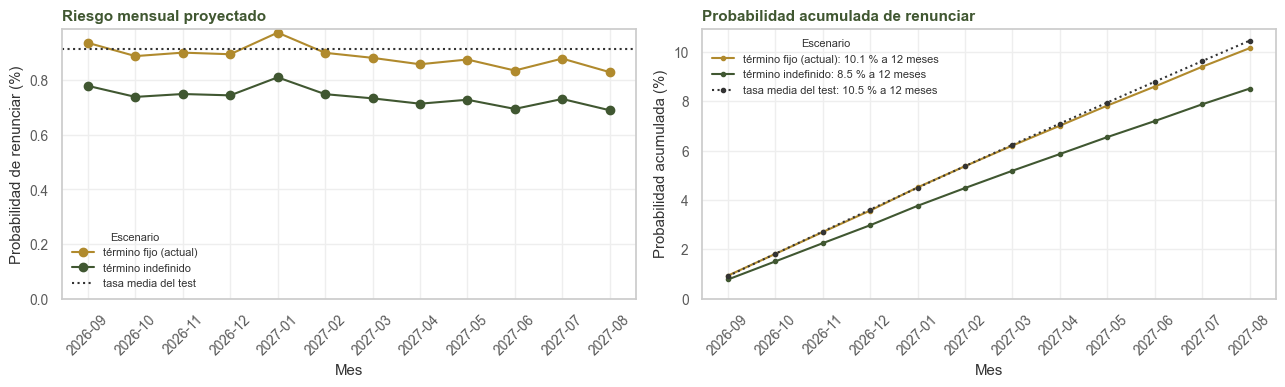

         término fijo (actual)  término indefinido  tasa media del test
mes                                                                    
2026-09                   0.94                0.78                 0.92
2027-02                   5.37                4.48                 5.37
2027-08                  10.15                8.51                10.45


In [14]:
# El caso, escrito a mano: sus valores de agosto de 2026, con un puesto administrativo genérico
caso = pd.Series({
    'mes': '2026-08', 'edad': 22, 'antig_meses': 46,
    'primer_mes': 0, 'reingreso': 0, 'traslado_12m': 0,
    'sociedad': 'S01', 'linea': 'palma', 'ubicacion': 'U002', 'genero': 'Masculino',
    'estado_civil': 'Soltero', 'contrato': 'Termino Fijo', 'nivel': '3_asistente',
    'familia_cargo': 'finanzas_administracion', 'oficio': 'administrativo',
    'tipo_unidad': 'area_funcional', 'area_funcional': 'finanzas_administracion',
    'proceso_planta': 'no_aplica', 'tipo_costos': 'ADMINISTRATIVO',
})
VISIBLES = ['edad', 'antig_meses', 'contrato', 'linea', 'nivel', 'tipo_costos']
print(caso[VISIBLES].rename(NOMBRE).to_string())


def proyectar(fila, meses=12, **cambios):
    """Filas de los próximos meses: la antigüedad suma uno por mes, la edad sube a los 12 meses y el
    mes del año rota; las demás variables se mantienen, salvo las que se cambien."""
    filas = []
    for k in range(1, meses + 1):
        f = fila.copy()
        for columna, valor in cambios.items():
            f[columna] = valor
        f['mes'] = str(pd.Period(fila.mes, 'M') + k)
        f['mes_anio'] = f['mes'][5:]
        f['antig_meses'] = fila.antig_meses + k
        f['edad'] = fila.edad + k // 12
        f['primer_mes'] = 0
        filas.append(f)
    return pd.DataFrame(filas)


CALIBRADO = FIN['logistica_sin_pesos']
escenarios = {'término fijo (actual)': proyectar(caso),
              'término indefinido': proyectar(caso, contrato='Termino Indefinido')}
riesgo = pd.DataFrame({nombre: CALIBRADO.predict_proba(d[X_COLS])[:, 1]
                       for nombre, d in escenarios.items()},
                      index=escenarios['término fijo (actual)'].mes)
acumulada = 1 - (1 - riesgo).cumprod()
base = te[OBJETIVO].mean()
acumulada['tasa media del test'] = 1 - (1 - base) ** np.arange(1, 13)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for (nombre, color) in zip(riesgo.columns, [ORO, VERDE]):
    ax[0].plot(riesgo.index, 100 * riesgo[nombre], marker='o', color=color, label=nombre)
ax[0].axhline(100 * base, ls=':', c=TINTA, label='tasa media del test')
ax[0].set(title='Riesgo mensual proyectado', xlabel='Mes', ylabel='Probabilidad de renunciar (%)')
for (nombre, color) in zip(acumulada.columns, [ORO, VERDE, TINTA]):
    estilo_linea = ':' if nombre == 'tasa media del test' else '-'
    ax[1].plot(acumulada.index, 100 * acumulada[nombre], ls=estilo_linea, marker='o', ms=3,
               color=color, label=f'{nombre}: {100 * acumulada[nombre].iloc[-1]:.1f} % a 12 meses')
ax[1].set(title='Probabilidad acumulada de renunciar', xlabel='Mes',
          ylabel='Probabilidad acumulada (%)')
for a in ax:
    a.tick_params(axis='x', rotation=45)
    a.set_ylim(bottom=0)
    a.legend(fontsize=8, title='Escenario', title_fontsize=8)
plt.tight_layout()
plt.show()

print((100 * acumulada.iloc[[0, 5, 11]]).round(2).to_string())

El caso tiene un riesgo mensual cercano al promedio: 0,94 % en septiembre de 2026, frente a 0,92 %
de la tasa media del test, y una probabilidad de renunciar en los próximos doce meses de 10,2 %,
casi igual a la de una persona con la tasa media (10,5 %). Sus variables se compensan: la juventud y el
término fijo suben el riesgo, y el personal administrativo y una antigüedad de casi cuatro años lo
bajan. El pico de enero es el efecto de calendario del capítulo 5, y el descenso gradual, el de la
antigüedad.

Con término indefinido, el riesgo mensual baja cerca de 17 % y la probabilidad a doce meses pasa a
8,5 %. El cambio es mucho menor que la razón de 3,7 del capítulo 3, porque buena parte de esa
diferencia corresponde a la antigüedad, que el modelo ya incluye (sección 7.9). Dos cautelas: el
escenario de contrato es una comparación dentro del modelo y no un efecto causal (sección 7.11), y
las probabilidades están calibradas al nivel del entrenamiento, algo por encima del de los meses
recientes (sección 7.8).

## Limitaciones

- **Ventana corta.** Veinte meses de datos: solo dos eneros, sin estimación de la componente
  estacional y con poca potencia para detectar cambios de nivel (capítulo 5).
- **Variables que faltan.** El panel no tiene salario, desempeño, clima laboral ni condiciones del
  mercado local, que suelen explicar buena parte de las renuncias. Parte de lo que el modelo atribuye
  al contrato, la línea o la sociedad puede venir de esas variables.
- **Una sola organización.** Los datos son de un grupo empresarial agroindustrial, con predominio de
  personal operativo de campo. Las conclusiones no se extienden a otros sectores ni a otras empresas.
- **Etiqueta y riesgos competitivos.** La renuncia es la registrada en SAP como voluntaria. Las
  otras salidas se tratan como censura, lo que supone que no informan sobre el riesgo de renunciar, y
  los casos de etiqueta dudosa se excluyeron (sección 1.2).
- **Dependencia entre filas.** Los intervalos del análisis exploratorio tratan las filas como
  independientes y son algo optimistas; los del modelo usan bootstrap por personas.
- **Deriva.** La tasa del periodo reciente es menor que la del entrenamiento, y las probabilidades
  deben recalibrarse antes de usarse como tales (sección 7.8).
- **Asociación, no causa.** Los coeficientes describen asociaciones condicionadas a las demás
  variables. No indican qué pasaría si se cambiara el contrato de una persona, porque quien tiene
  término fijo difiere en otras cosas que el panel no mide.
- **Uso del puntaje.** Un puntaje individual de riesgo de renuncia puede usarse para retener, pero
  también para decidir contrataciones o renovaciones en contra de las personas marcadas. El libro
  publica solo resultados agregados, y el análisis de equidad por género y tipo de contrato queda
  pendiente para el proyecto final.

## Síntesis

1. La regresión logística supera a los modelos triviales. En la validación temporal gana en los
   ocho pliegues (PR-AUC +0,025, IC 95 % de +0,020 a +0,031; *t* pareada p < 0,001, Wilcoxon
   p = 0,008). En el test obtiene una PR-AUC de 0,029 (IC de 0,022 a 0,044) frente a 0,009 del
   dummy y un ROC-AUC de 0,76 (0,73 a 0,79); el 10 % de mayor riesgo de cada mes reúne el 31 % de las
   renuncias (24 % a 39 %), frente al 12 % del dummy.
2. No hay sobreajuste relevante: la brecha en ROC-AUC entre entrenamiento y validación es de
   +0,023 (2,9 % relativo), por debajo del 5 % aceptable. La validación temporal (PR-AUC 0,035), la
   agrupada por persona (0,039) y el test (0,029) están en el mismo rango. La regularización elegida
   es fuerte (C = 0,003) y la curva de aprendizaje se aplana: más filas del mismo tipo no
   mejorarían el modelo.
3. Con la lista del 10 % mensual, la exhaustividad es 0,31, la precisión 0,029 y el F2 0,106 (0,078
   a 0,130), frente a 0,044 de marcar a todos. El F2 varía poco entre listas del 5 % y el 15 % (0,11
   a 0,13 en validación), de modo que el tamaño se puede fijar según la capacidad operativa. La
   exactitud (0,90) no es informativa: el dummy estratificado obtiene 0,98 sin identificar ninguna
   renuncia.
4. La versión balanceada ordena mejor en validación (+0,0035 de PR-AUC, p = 0,03) y en el test
   empata con la sin pesos, pero infla las probabilidades (predice entre 8 % y 75 % donde la
   frecuencia real va de 0,05 % a 3 %). Si el puntaje se interpreta como probabilidad, se usa la
   versión sin pesos o se recalibra.
5. Los residuos no tienen autocorrelación (Ljung-Box p = 0,25), pero en 10 de los 12 meses el modelo
   espera más renuncias de las observadas (unas 49 frente a 42 al mes), porque la tasa del periodo
   reciente es menor (0,92 % en test frente a 1,08 %). El orden de riesgo no se afecta; el nivel
   debería recalibrarse con los meses recientes.

Para el proyecto final quedan los modelos con interacciones (árboles con gradiente), la
codificación suavizada de las categóricas grandes, la recalibración temporal y un análisis de
equidad del puntaje por género y tipo de contrato.